Chapter 11
# 用Matplotlib和Plotly可视化三维随机行走
Book_1《编程不难》 | 鸢尾花书：从加减乘除到机器学习 

In [1]:
# ===== 1) 导入依赖库 =====
# Matplotlib：绘制静态 3D 图
import matplotlib.pyplot as plt
# NumPy：生成随机数、进行数组运算
import numpy as np
# Plotly：绘制可交互 3D 图（可旋转、缩放）
import plotly.graph_objects as go


In [2]:
# ===== 2) 生成 3D 随机游走数据 =====
# 轨迹总步数
num_steps = 300
# 时间索引（0~299），后面用于给散点着色
t = np.arange(num_steps)
# standard_normal 先生成每一步的随机增量 dx/dy/dz
# cumsum 再将增量累加成位置坐标 x/y/z（形成连续轨迹）
x = np.cumsum(np.random.standard_normal(num_steps))
y = np.cumsum(np.random.standard_normal(num_steps))
z = np.cumsum(np.random.standard_normal(num_steps))


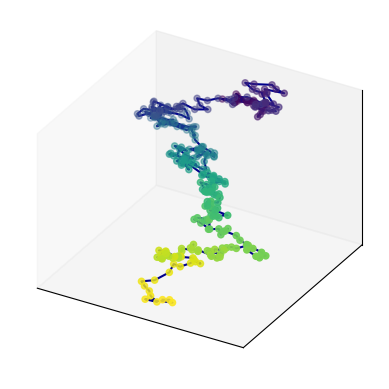

In [3]:
# ===== 3) Matplotlib：静态 3D 可视化 =====
# 创建画布
fig = plt.figure()
# 添加 3D 坐标轴（111 表示 1x1 网格中的第 1 个子图）
ax = fig.add_subplot(111, projection='3d')

# 画轨迹线：按照点的顺序连接 (x[i], y[i], z[i])
ax.plot(x, y, z, color='darkblue')
# 画散点：每个时间步一个点，颜色随 t 变化
ax.scatter(x, y, z, c=t, cmap='viridis')

# 隐藏 xyz 轴刻度，让注意力集中在轨迹形状上
ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
# 使用正交投影，避免透视缩短效果
ax.set_proj_type('ortho')
# 设置观察角度：elev 是仰角，azim 是方位角
ax.view_init(elev=30, azim=120)
# 显示图像
plt.show()


In [6]:
# ===== 4) Plotly：交互式 3D 可视化 =====
# lines+markers：同时显示连接线和点
fig = go.Figure(data=go.Scatter3d(
    x=x, y=y, z=z,
    mode='lines+markers',
    # marker 控制点样式：大小、颜色映射、色带
    marker=dict(size=4, color=t, colorscale='Viridis'),
    # line 控制轨迹线样式
    line=dict(color='darkblue', width=2)
))

# 设置 3D 相机为正交投影（与 Matplotlib 一致）
fig.layout.scene.camera.projection.type = 'orthographic'
# 设置图像尺寸
fig.update_layout(width=800, height=700)
# 显示交互图
fig.show()
